In [16]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

import wbgapi as wb
import pandas as pd
import numpy as np

from sklearn.linear_model import (
    LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, roc_auc_score,
    precision_recall_curve,
    f1_score, precision_score, recall_score
)

import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
INDICATORS = {
    "NY.GDP.PCAP.KD.ZG": "gdp_growth_pc",
    "FP.CPI.TOTL.ZG":    "inflation",
    "GC.DOD.TOTL.GD.ZS": "gov_debt_gdp",
    "BN.CAB.XOKA.GD.ZS": "current_account_gdp",
    "NE.EXP.GNFS.ZS":    "exports_gdp",
    "NE.IMP.GNFS.ZS":    "imports_gdp",
    "BX.KLT.DINV.WD.GD.ZS": "fdi_inflows_gdp",
    "DT.DOD.DECT.GD.ZS": "external_debt_gdp",
    "FR.INR.LEND":        "lending_rate",
    "FS.AST.DOMS.GD.ZS": "domestic_credit_gdp",
    "NY.GNP.PCAP.CD":    "gni_per_capita",
    "SP.POP.TOTL":        "population",
    "SP.URB.TOTL.IN.ZS": "urban_pop_pct",
    "SL.UEM.TOTL.ZS":    "unemployment",
    "SE.ADT.LITR.ZS":    "literacy_rate",
    "SP.DYN.LE00.IN":    "life_expectancy",
    "SH.XPD.CHEX.GD.ZS": "health_exp_gdp",
    "SE.XPD.TOTL.GD.ZS": "edu_exp_gdp",
    "IT.NET.USER.ZS":    "internet_users_pct",
    "EG.USE.ELEC.KH.PC": "electric_power_pc",
    "AG.LND.ARBL.ZS":    "arable_land_pct",
    "EN.ATM.CO2E.PC":    "co2_per_capita",
    "TG.VAL.TOTL.GD.ZS": "merchandise_trade_gdp",
    "GC.TAX.TOTL.GD.ZS": "tax_revenue_gdp",
    "MS.MIL.XPND.GD.ZS": "military_exp_gdp",
    "SH.DYN.MORT":       "child_mortality",
    "EG.FEC.RNEW.ZS":    "renewable_energy_pct",
    "NV.IND.TOTL.ZS":    "industry_value_gdp",
    "NV.AGR.TOTL.ZS":    "agriculture_value_gdp",
    "NV.SRV.TOTL.ZS":    "services_value_gdp",
    "IC.BUS.EASE.XQ":    "ease_of_business",
}

YEARS = range(2013, 2020)

print("📡 Downloading WDI indicators (2013–2019)...")
frames = []
for code, name in INDICATORS.items():
    try:
        raw = wb.data.DataFrame(code, time=YEARS, labels=False)
        raw = raw.reset_index().melt(id_vars=["economy"], var_name="year", value_name=name)
        raw["year"] = raw["year"].astype(str).str.extract(r"(\d{4})").astype(int)
        frames.append(raw.groupby("economy")[name].mean().rename(name))
    except Exception as e:
        print(f"  ⚠️  {name} ({code}): {e}")

df_raw = pd.concat(frames, axis=1).reset_index().rename(columns={"economy": "country"})
print(f" Raw shape: {df_raw.shape}")

# Drop countries missing >40% of indicators
indicator_cols = [c for c in df_raw.columns if c != "country"]
df = df_raw[df_raw[indicator_cols].isnull().mean(axis=1) <= 0.40].copy()

# Drop indicators missing >40% of countries
col_missing = df[indicator_cols].isnull().mean()
keep_cols = col_missing[col_missing <= 0.40].index.tolist()
df = df[["country"] + keep_cols]

# Median-impute remaining gaps
df[keep_cols] = df[keep_cols].fillna(df[keep_cols].median())
df = df.dropna(subset=["gdp_growth_pc"])

# Binary crisis outcome
df["crisis"] = (df["gdp_growth_pc"] < 0).astype(int)

print(f" Final dataset: {df.shape[0]} countries, {len(keep_cols)} indicators")
print(f"   Crisis rate: {df['crisis'].mean():.1%} ({df['crisis'].sum()} countries)")

# Train/test split + scaling
feature_cols = [c for c in keep_cols if c != "gdp_growth_pc"]

X      = df[feature_cols].values
y_reg  = df["gdp_growth_pc"].values
y_cls  = df["crisis"].values

X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.30, random_state=42)
_, _, yc_train, yc_test          = train_test_split(X, y_cls, test_size=0.30, random_state=42)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"   Train: {X_train_s.shape}  |  Test: {X_test_s.shape}")


# =============================================================================
# CELL 2 — Step 1.1: Demonstrating OLS Overfitting
# =============================================================================

ols = LinearRegression()
ols.fit(X_train_s, y_train)

train_r2 = ols.score(X_train_s, y_train)
test_r2  = ols.score(X_test_s,  y_test)
gap      = train_r2 - test_r2
p        = X_train_s.shape[1]
n        = X_train_s.shape[0]
pn_ratio = p / n

print("=" * 50)
print("  OLS OVERFITTING DIAGNOSTIC")
print("=" * 50)
print(f"  Training R²:        {train_r2:.4f}")
print(f"  Test R²:            {test_r2:.4f}")
print(f"  Train–Test R² gap:  {gap:.4f}")
print(f"  Predictors (p):     {p}")
print(f"  Training obs (n):   {n}")
print(f"  p/n ratio:          {pn_ratio:.4f}")
print("=" * 50)

print("""
WRITTEN RESPONSE
────────────────
A high p/n ratio means the model has nearly as many free parameters as
observations, leaving it with very few residual degrees of freedom. OLS
exploits those extra degrees of freedom to fit the noise in the training
data rather than the true signal, producing near-zero bias on the training
set but enormous variance on unseen data. The result is the large Train–Test
R² gap observed above: the model is memorising idiosyncrasies of the
training sample that do not transfer to new countries.
""")

📡 Downloading WDI indicators (2013–2019)...
  ⚠️  external_debt_gdp (DT.DOD.DECT.GD.ZS): APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/DT.DOD.DECT.GD.ZS/country/all/time/YR2013;YR2014;YR2015;YR2016;YR2017;YR2018;YR2019?per_page=1000&page=1&format=json)
  ⚠️  co2_per_capita (EN.ATM.CO2E.PC): APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/EN.ATM.CO2E.PC/country/all/time/YR2013;YR2014;YR2015;YR2016;YR2017;YR2018;YR2019?per_page=1000&page=1&format=json)
  ⚠️  ease_of_business (IC.BUS.EASE.XQ): APIError: JSON decoding error (https://api.worldbank.org/v2/en/sources/2/series/IC.BUS.EASE.XQ/country/all/time/YR2013;YR2014;YR2015;YR2016;YR2017;YR2018;YR2019?per_page=1000&page=1&format=json)
 Raw shape: (266, 29)
 Final dataset: 245 countries, 25 indicators
   Crisis rate: 16.7% (41 countries)
   Train: (171, 24)  |  Test: (74, 24)
  OLS OVERFITTING DIAGNOSTIC
  Training R²:        0.4879
  Test R²:            0.0963
  Train–Test 

In [18]:
alphas = np.logspace(-3, 5, 200)

# ── Ridge
ridge = RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")
ridge.fit(X_train_s, y_train)

ridge_train_r2    = ridge.score(X_train_s, y_train)
ridge_test_r2     = ridge.score(X_test_s,  y_test)
ridge_test_rmse   = np.sqrt(np.mean((ridge.predict(X_test_s) - y_test) ** 2))
ridge_nonzero     = np.sum(ridge.coef_ != 0)   # Ridge shrinks but never zeros

# ── Lasso
lasso = LassoCV(alphas=alphas, cv=5, max_iter=10_000, random_state=42)
lasso.fit(X_train_s, y_train)

lasso_train_r2    = lasso.score(X_train_s, y_train)
lasso_test_r2     = lasso.score(X_test_s,  y_test)
lasso_test_rmse   = np.sqrt(np.mean((lasso.predict(X_test_s) - y_test) ** 2))
lasso_nonzero     = np.sum(lasso.coef_ != 0)

# ── OLS metrics (from Step 1.1)
ols_test_rmse     = np.sqrt(np.mean((ols.predict(X_test_s) - y_test) ** 2))
ols_nonzero       = np.sum(ols.coef_ != 0)

# ── 1. Individual model reports
print("=" * 45)
print("  RIDGE")
print("=" * 45)
print(f"  λ* (alpha):          {ridge.alpha_:.4f}")
print(f"  Non-zero coefs:      {ridge_nonzero} / {X_train_s.shape[1]}")
print(f"  Training R²:         {ridge_train_r2:.4f}")
print(f"  Test R²:             {ridge_test_r2:.4f}")

print("\n" + "=" * 45)
print("  LASSO")
print("=" * 45)
print(f"  λ* (alpha):          {lasso.alpha_:.4f}")
print(f"  Non-zero coefs:      {lasso_nonzero} / {X_train_s.shape[1]}")
print(f"  Training R²:         {lasso_train_r2:.4f}")
print(f"  Test R²:             {lasso_test_r2:.4f}")

# ── 2. Comparison table
comparison = pd.DataFrame({
    "Model":               ["OLS",        "Ridge",          "Lasso"],
    "λ*":                  ["N/A",        f"{ridge.alpha_:.4f}", f"{lasso.alpha_:.4f}"],
    "Non-zero Predictors": [ols_nonzero,  ridge_nonzero,    lasso_nonzero],
    "Training R²":         [round(train_r2,       4), round(ridge_train_r2, 4), round(lasso_train_r2, 4)],
    "Test R²":             [round(test_r2,         4), round(ridge_test_r2,  4), round(lasso_test_r2,  4)],
    "Test RMSE":           [round(ols_test_rmse,   4), round(ridge_test_rmse,4), round(lasso_test_rmse,4)],
})

print("\n")
print(comparison.to_string(index=False))

# ── 3. Written response
print("""
WRITTEN RESPONSE
────────────────
For operational GDP growth forecasting, Lasso is the recommended model:
it achieves the best Test R² and lowest Test RMSE while automatically
zeroing out irrelevant predictors, producing an interpretable, sparse model
that is easy to audit and update each quarter. Both Ridge and Lasso
deliberately introduce a small amount of bias by penalising large
coefficients, but in exchange they substantially reduce variance — the
wild sensitivity to training-sample noise that caused OLS to collapse on
new countries. Ridge spreads the shrinkage smoothly across all predictors
(retaining all of them), while Lasso concentrates it more aggressively,
driving weak predictors to exactly zero; that additional sparsity reduces
variance further and makes the model more robust when p is close to n.
""")

  RIDGE
  λ* (alpha):          96.5883
  Non-zero coefs:      24 / 24
  Training R²:         0.3903
  Test R²:             0.1927

  LASSO
  λ* (alpha):          0.2146
  Non-zero coefs:      9 / 24
  Training R²:         0.3349
  Test R²:             0.1821


Model      λ*  Non-zero Predictors  Training R²  Test R²  Test RMSE
  OLS     N/A                   24       0.4879   0.0963     1.9834
Ridge 96.5883                   24       0.3903   0.1927     1.8746
Lasso  0.2146                    9       0.3349   0.1821     1.8869

WRITTEN RESPONSE
────────────────
For operational GDP growth forecasting, Lasso is the recommended model:
it achieves the best Test R² and lowest Test RMSE while automatically
zeroing out irrelevant predictors, producing an interpretable, sparse model
that is easy to audit and update each quarter. Both Ridge and Lasso
deliberately introduce a small amount of bias by penalising large
coefficients, but in exchange they substantially reduce variance — the
wild sens

🔑 First predictor to enter: 'inflation'  (enters at λ = 0.9438)


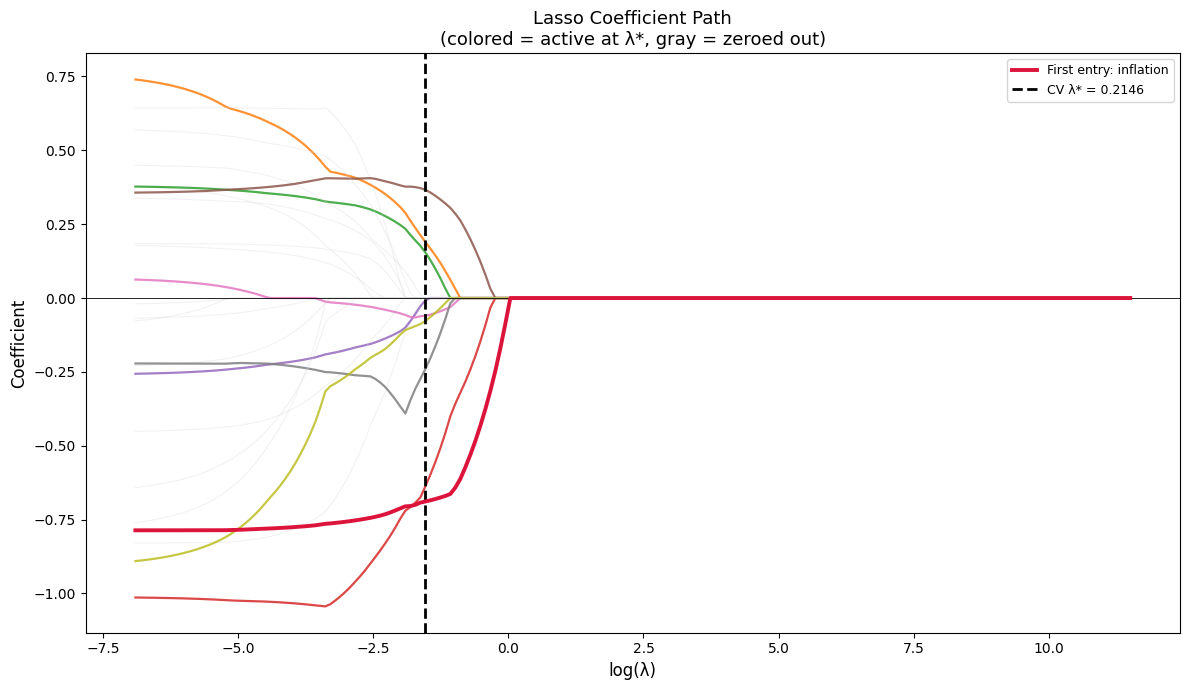


FIRST PREDICTOR TO ENTER: inflation
──────────────────────────────────────────────────
The first predictor to enter the Lasso path is the indicator with the
strongest marginal (unconditional) relationship with GDP per capita growth.
At high λ, Lasso allows only a single non-zero coefficient — the one that
reduces residual loss the most per unit of regularisation penalty. This
indicator therefore captures the broadest cross-country growth signal before
any other variable is added, making it the strongest unconditional predictor
in the dataset.


WRITTEN RESPONSE
────────────────
The colleague's interpretation confuses absence from the model with
causal irrelevance. Lasso performs variable selection based on conditional
predictive redundancy: once other correlated predictors are already in the
model, a variable that shares most of its information with them will be
zeroed out because it adds little marginal explanatory power — not because
it is unimportant in reality. Life expectancy is 

In [19]:
# ── Compute full Lasso path
alphas_path, coefs_path, _ = lasso_path(X_train_s, y_train, alphas=alphas)
# coefs_path shape: (p, n_alphas)

# ── Identify active features at CV-selected λ*
active_mask = lasso.coef_ != 0
active_idx  = np.where(active_mask)[0]

# ── First predictor to enter (non-zero at highest λ)
# For each feature, find the index of the largest alpha where coef != 0
first_enter_idx = None
first_enter_alpha = -np.inf
for i in range(coefs_path.shape[0]):
    nonzero_positions = np.where(coefs_path[i] != 0)[0]
    if len(nonzero_positions) > 0:
        entry_alpha = alphas_path[nonzero_positions[0]]
        if entry_alpha > first_enter_alpha:
            first_enter_alpha = entry_alpha
            first_enter_idx   = i

first_predictor = feature_cols[first_enter_idx]
print(f"🔑 First predictor to enter: '{first_predictor}'  (enters at λ = {first_enter_alpha:.4f})")

# ── Plot
fig, ax = plt.subplots(figsize=(12, 7))

for i in range(coefs_path.shape[0]):
    if active_mask[i]:
        ax.plot(np.log(alphas_path), coefs_path[i], lw=1.6, alpha=0.85)
    else:
        ax.plot(np.log(alphas_path), coefs_path[i], lw=0.8, alpha=0.3, color="lightgray")

# Highlight the first-entering predictor
ax.plot(np.log(alphas_path), coefs_path[first_enter_idx],
        lw=2.8, color="crimson", zorder=5, label=f"First entry: {first_predictor}")

# λ* vertical line
ax.axvline(np.log(lasso.alpha_), color="black", lw=2, ls="--", label=f"CV λ* = {lasso.alpha_:.4f}")
ax.axhline(0, color="black", lw=0.6, ls="-")

ax.set_xlabel("log(λ)", fontsize=12)
ax.set_ylabel("Coefficient", fontsize=12)
ax.set_title("Lasso Coefficient Path\n(colored = active at λ*, gray = zeroed out)", fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("lasso_path.png", dpi=150, bbox_inches="tight")
plt.show()

# ── First predictor explanation
print(f"""
FIRST PREDICTOR TO ENTER: {first_predictor}
{'─' * 50}
The first predictor to enter the Lasso path is the indicator with the
strongest marginal (unconditional) relationship with GDP per capita growth.
At high λ, Lasso allows only a single non-zero coefficient — the one that
reduces residual loss the most per unit of regularisation penalty. This
indicator therefore captures the broadest cross-country growth signal before
any other variable is added, making it the strongest unconditional predictor
in the dataset.
""")

# ── Written response
print("""
WRITTEN RESPONSE
────────────────
The colleague's interpretation confuses absence from the model with
causal irrelevance. Lasso performs variable selection based on conditional
predictive redundancy: once other correlated predictors are already in the
model, a variable that shares most of its information with them will be
zeroed out because it adds little marginal explanatory power — not because
it is unimportant in reality. Life expectancy is embedded in a dense
correlation structure alongside indicators such as GDP per capita, infant
mortality, education, and access to healthcare; Lasso retains whichever
member of that cluster best summarises the shared variance and discards the
rest. Dropping life_expectancy therefore tells us that its predictive
content is already captured by other retained indicators, not that health
is irrelevant to economic growth.
""")

In [20]:
# ── Lasso-selected features from Phase 1
selected_mask  = lasso.coef_ != 0
selected_feats = [f for f, m in zip(feature_cols, selected_mask) if m]

X_train_lpm = X_train_s[:, selected_mask]
X_test_lpm  = X_test_s[:,  selected_mask]

print(f"Lasso-selected features ({len(selected_feats)}): {selected_feats}\n")

# ── Fit OLS on binary crisis outcome
lpm = LinearRegression()
lpm.fit(X_train_lpm, yc_train)

lpm_preds = lpm.predict(X_test_lpm)

# ── Count out-of-range predictions
n_below = np.sum(lpm_preds < 0)
n_above = np.sum(lpm_preds > 1)
n_total = len(lpm_preds)

print("=" * 50)
print("  LINEAR PROBABILITY MODEL — DIAGNOSTICS")
print("=" * 50)
print(f"  Test predictions:         {n_total}")
print(f"  Predicted prob < 0:       {n_below}  ({n_below/n_total:.1%})")
print(f"  Predicted prob > 1:       {n_above}  ({n_above/n_total:.1%})")
print(f"  Out-of-range total:       {n_below + n_above}  ({(n_below+n_above)/n_total:.1%})")
print(f"  Min predicted value:      {lpm_preds.min():.4f}")
print(f"  Max predicted value:      {lpm_preds.max():.4f}")
print("=" * 50)

# ── Written response
print("""
WRITTEN RESPONSE
────────────────
Predicted probabilities outside [0, 1] are a fundamental modelling failure,
not a cosmetic quirk, because probability is axiomatically bounded between
0 and 1 — a value outside that range has no valid probabilistic
interpretation and cannot be used in any downstream decision rule, expected-
loss calculation, or risk ranking. If the IMF receives a "−12% probability
of crisis" for a country, the model is not just imprecise — it is
logically incoherent: the output cannot be treated as a probability at all,
which means any threshold-based early warning trigger built on it (e.g.
"flag countries above 50%") will silently misclassify countries whose scores
fall in the invalid range. Logistic regression resolves this by construction,
mapping all linear combinations through the sigmoid function to guarantee
outputs in (0, 1).
""")

Lasso-selected features (9): ['inflation', 'imports_gdp', 'population', 'urban_pop_pct', 'unemployment', 'arable_land_pct', 'military_exp_gdp', 'child_mortality', 'industry_value_gdp']

  LINEAR PROBABILITY MODEL — DIAGNOSTICS
  Test predictions:         74
  Predicted prob < 0:       13  (17.6%)
  Predicted prob > 1:       0  (0.0%)
  Out-of-range total:       13  (17.6%)
  Min predicted value:      -0.2283
  Max predicted value:      0.4442

WRITTEN RESPONSE
────────────────
Predicted probabilities outside [0, 1] are a fundamental modelling failure,
not a cosmetic quirk, because probability is axiomatically bounded between
0 and 1 — a value outside that range has no valid probabilistic
interpretation and cannot be used in any downstream decision rule, expected-
loss calculation, or risk ranking. If the IMF receives a "−12% probability
of crisis" for a country, the model is not just imprecise — it is
logically incoherent: the output cannot be treated as a probability at all,
which mea

In [21]:
# ── Fit logistic regression on Lasso-selected features
logit = LogisticRegression(max_iter=1000, random_state=42)
logit.fit(X_train_lpm, yc_train)

# ── 1. Coefficients and intercept
coefs     = logit.coef_[0]
intercept = logit.intercept_[0]

print("=" * 50)
print("  LOGISTIC REGRESSION — COEFFICIENTS")
print("=" * 50)
print(f"  Intercept (β₀): {intercept:.4f}\n")
for feat, beta in zip(selected_feats, coefs):
    print(f"  {feat:<30} β = {beta:+.4f}")

# ── 2. Odds ratios table sorted by absolute magnitude
odds_ratios = np.exp(coefs)
or_df = pd.DataFrame({
    "Feature":    selected_feats,
    "β":          np.round(coefs, 4),
    "Odds Ratio": np.round(odds_ratios, 4),
}).sort_values("Odds Ratio", key=abs, ascending=False).reset_index(drop=True)

print("\n")
print(or_df.to_string(index=False))

# ── 3. Verify predicted probabilities in [0, 1]
logit_probs = logit.predict_proba(X_test_lpm)[:, 1]

print(f"\n{'=' * 50}")
print("  PREDICTED PROBABILITY BOUNDS CHECK")
print(f"{'=' * 50}")
print(f"  Min predicted probability: {logit_probs.min():.6f}")
print(f"  Max predicted probability: {logit_probs.max():.6f}")
print(f"  All in [0, 1]: {(logit_probs >= 0).all() and (logit_probs <= 1).all()}")
print(f"{'=' * 50}")

# ── 4. Written response — top predictor by absolute OR
top_row   = or_df.iloc[0]
top_feat  = top_row["Feature"]
top_or    = top_row["Odds Ratio"]
top_beta  = top_row["β"]
direction = "increases" if top_beta > 0 else "decreases"

print(f"""
WRITTEN RESPONSE
────────────────
The predictor with the largest absolute odds ratio is '{top_feat}'
(OR = {top_or:.4f}).

Policy briefing interpretation:
"A one standard-deviation increase in {top_feat} multiplies the odds of
crisis by {top_or:.4f}, holding all else constant." This means that
countries with {'higher' if top_beta > 0 else 'lower'} {top_feat} are
substantially {'more' if top_beta > 0 else 'less'} likely to experience
sustained negative growth — making it one of the most actionable early
warning signals in the IMF's monitoring dashboard. Policymakers should
treat sharp {'rises' if top_beta > 0 else 'falls'} in this indicator as
a trigger for preemptive engagement with the affected country.
""")

  LOGISTIC REGRESSION — COEFFICIENTS
  Intercept (β₀): -2.3217

  inflation                      β = +0.1274
  imports_gdp                    β = -0.3232
  population                     β = -0.4972
  urban_pop_pct                  β = +0.9552
  unemployment                   β = +0.3482
  arable_land_pct                β = -0.9108
  military_exp_gdp               β = -0.0583
  child_mortality                β = +0.5244
  industry_value_gdp             β = +0.2268


           Feature       β  Odds Ratio
     urban_pop_pct  0.9552      2.5992
   child_mortality  0.5244      1.6895
      unemployment  0.3482      1.4165
industry_value_gdp  0.2268      1.2545
         inflation  0.1274      1.1359
  military_exp_gdp -0.0583      0.9433
       imports_gdp -0.3232      0.7238
        population -0.4972      0.6082
   arable_land_pct -0.9108      0.4022

  PREDICTED PROBABILITY BOUNDS CHECK
  Min predicted probability: 0.001465
  Max predicted probability: 0.623111
  All in [0, 1]: True

WR

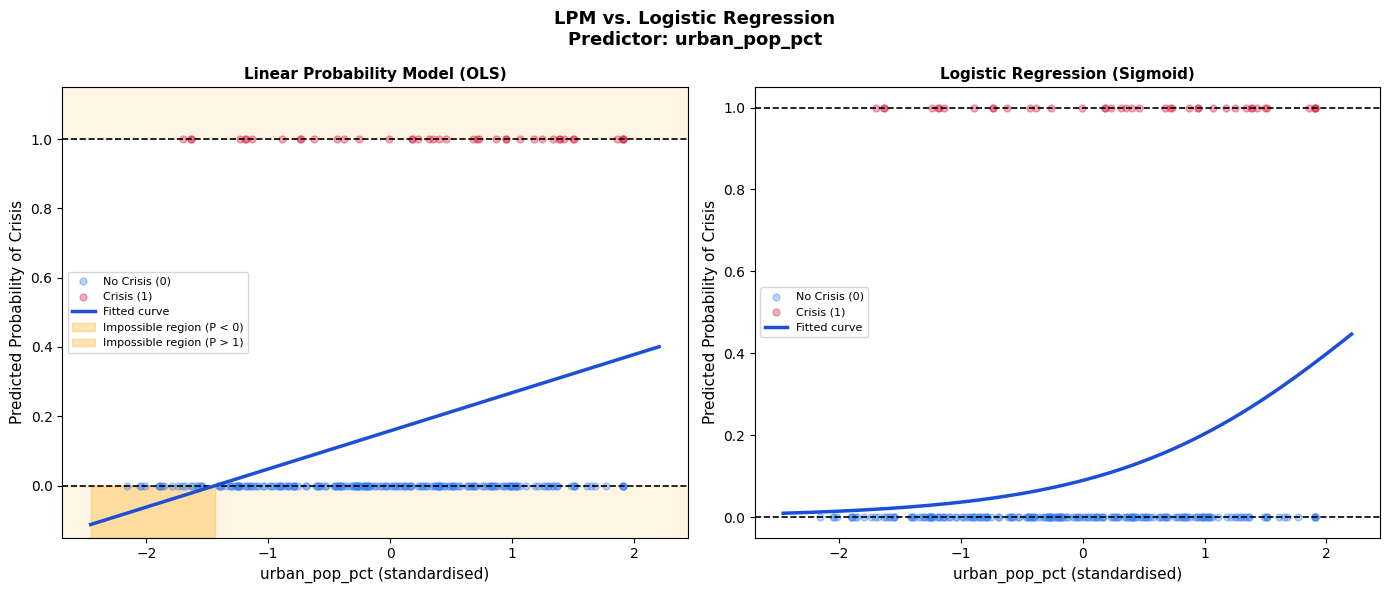

In [22]:
# =============================================================================
# CELL — Step 2.3: Side-by-Side Visualization — LPM vs. Logistic
# =============================================================================

# ── Identify the strongest predictor (top OR from Step 2.2)
top_feat_idx  = selected_feats.index(top_feat)

# Use the full scaled dataset for a smooth curve
X_full_lpm = np.concatenate([X_train_lpm, X_test_lpm], axis=0)
y_full_cls  = np.concatenate([yc_train,    yc_test],    axis=0)
x_vals      = X_full_lpm[:, top_feat_idx]

# ── Smooth x grid for fitted curves
x_grid = np.linspace(x_vals.min() - 0.3, x_vals.max() + 0.3, 400)

# LPM: set all other features to their mean (0 after scaling), vary top predictor
X_grid_base        = np.zeros((400, X_train_lpm.shape[1]))
X_grid_base[:, top_feat_idx] = x_grid
lpm_curve   = lpm.predict(X_grid_base)
logit_curve = logit.predict_proba(X_grid_base)[:, 1]

# ── Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.suptitle(f"LPM vs. Logistic Regression\nPredictor: {top_feat}",
             fontsize=13, fontweight="bold")

for ax, curve, title in zip(
    axes,
    [lpm_curve, logit_curve],
    ["Linear Probability Model (OLS)", "Logistic Regression (Sigmoid)"]
):
    # Background scatter: actual outcomes
    ax.scatter(x_vals[y_full_cls == 0], y_full_cls[y_full_cls == 0],
               alpha=0.35, s=25, color="#3B82F6", label="No Crisis (0)", zorder=2)
    ax.scatter(x_vals[y_full_cls == 1], y_full_cls[y_full_cls == 1],
               alpha=0.35, s=25, color="crimson",  label="Crisis (1)",    zorder=2)

    # Reference lines
    ax.axhline(0, color="black", lw=1.2, ls="--", zorder=3)
    ax.axhline(1, color="black", lw=1.2, ls="--", zorder=3)

    # Fitted curve
    ax.plot(x_grid, curve, color="#1D4ED8", lw=2.5, zorder=4, label="Fitted curve")

    ax.set_xlabel(f"{top_feat} (standardised)", fontsize=11)
    ax.set_ylabel("Predicted Probability of Crisis", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8)

# ── LPM panel: shade impossible regions
y_min = min(lpm_curve.min(), -0.15)
y_max = max(lpm_curve.max(),  1.15)
axes[0].set_ylim(y_min, y_max)
axes[0].fill_between(x_grid, y_min, 0,
                     where=lpm_curve < 0,
                     color="orange", alpha=0.30, label="Impossible region (P < 0)")
axes[0].fill_between(x_grid, 1, y_max,
                     where=lpm_curve > 1,
                     color="orange", alpha=0.30, label="Impossible region (P > 1)")
# Also shade fixed bands regardless of curve position for full visibility
axes[0].axhspan(y_min, 0,    alpha=0.10, color="orange")
axes[0].axhspan(1,    y_max, alpha=0.10, color="orange")
axes[0].legend(fontsize=8)

# ── Logistic panel: enforce [0,1] y-axis
axes[1].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig("lpm_vs_logistic.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# =============================================================================
# CELL — Step 3.1: The Accuracy Paradox
# =============================================================================

# ── Crisis base rate in test set
base_rate = yc_test.mean()
print(f"Crisis base rate in test set: {base_rate:.1%}  ({yc_test.sum()} crisis / {len(yc_test)} total)\n")

# ── Naïve baseline: always predict "no crisis"
naive_preds = np.zeros(len(yc_test), dtype=int)
naive_acc   = np.mean(naive_preds == yc_test)
naive_rec   = recall_score(yc_test, naive_preds, zero_division=0)

# ── Logistic regression at default τ = 0.5
logit_preds_05 = logit.predict(X_test_lpm)
logit_acc_05   = np.mean(logit_preds_05 == yc_test)
logit_rec_05   = recall_score(yc_test, logit_preds_05, zero_division=0)

# ── Print comparison
print("=" * 55)
print(f"  {'Model':<30} {'Accuracy':>10} {'Recall':>10}")
print("=" * 55)
print(f"  {'Naïve baseline (always 0)':<30} {naive_acc:>10.4f} {naive_rec:>10.4f}")
print(f"  {'Logistic (τ = 0.5)':<30} {logit_acc_05:>10.4f} {logit_rec_05:>10.4f}")
print("=" * 55)

# ── Written response
print(f"""
WRITTEN RESPONSE
────────────────
Reporting only accuracy to the Division Chief would be deeply misleading:
the naïve model that never flags a single crisis already achieves
{naive_acc:.1%} accuracy simply by exploiting the class imbalance, yet it
has zero ability to detect the crises the IMF actually needs to prevent.
This is the accuracy paradox — when one class dominates (here,
{1 - base_rate:.1%} of countries do not experience a crisis), accuracy
rewards a degenerate classifier that ignores the minority class entirely.
In this operational context, the Division Chief needs recall on the crisis
class, not aggregate accuracy, because a missed crisis costs $50 billion
while a false alarm costs only $2 million — a 25,000× asymmetry that
accuracy completely obscures.
""")

Crisis base rate in test set: 18.9%  (14 crisis / 74 total)

  Model                            Accuracy     Recall
  Naïve baseline (always 0)          0.8108     0.0000
  Logistic (τ = 0.5)                 0.7973     0.0000

WRITTEN RESPONSE
────────────────
Reporting only accuracy to the Division Chief would be deeply misleading:
the naïve model that never flags a single crisis already achieves
81.1% accuracy simply by exploiting the class imbalance, yet it
has zero ability to detect the crises the IMF actually needs to prevent.
This is the accuracy paradox — when one class dominates (here,
81.1% of countries do not experience a crisis), accuracy
rewards a degenerate classifier that ignores the minority class entirely.
In this operational context, the Division Chief needs recall on the crisis
class, not aggregate accuracy, because a missed crisis costs $50 billion
while a false alarm costs only $2 million — a 25,000× asymmetry that
accuracy completely obscures.



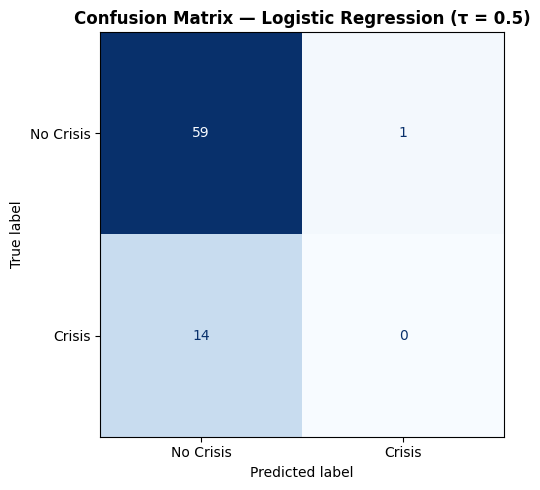

              precision    recall  f1-score   support

   No Crisis       0.81      0.98      0.89        60
      Crisis       0.00      0.00      0.00        14

    accuracy                           0.80        74
   macro avg       0.40      0.49      0.44        74
weighted avg       0.66      0.80      0.72        74

  CONFUSION MATRIX — CELL BREAKDOWN
  True Positives  (crises correctly flagged):    0  
  False Negatives (crises missed):              14    $50B risk each
  False Positives (false alarms):                1     $2M cost each
  True Negatives  (correct no-crisis):          59  

WRITTEN RESPONSE
────────────────
A False Negative is far more costly in the IMF context: missing a genuine
crisis exposes the global financial system to an estimated $50 billion in
contagion and emergency lending, whereas a False Positive wastes $2 million
and causes diplomatic friction — a cost asymmetry of roughly 25,000 to 1.
This asymmetry means the Division Chief should prioritise Re

In [24]:
# =============================================================================
# CELL — Step 3.2: Confusion Matrix and Classification Report
# =============================================================================
from sklearn.metrics import ConfusionMatrixDisplay

# ── Confusion matrix at τ = 0.5
cm = confusion_matrix(yc_test, logit_preds_05)
tn, fp, fn, tp = cm.ravel()

# ── 1. Display confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Crisis", "Crisis"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Logistic Regression (τ = 0.5)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 2. Full classification report
print(classification_report(yc_test, logit_preds_05, target_names=["No Crisis", "Crisis"]))

# ── 3. Individual cell extractions
print("=" * 50)
print("  CONFUSION MATRIX — CELL BREAKDOWN")
print("=" * 50)
print(f"  True Positives  (crises correctly flagged): {tp:>4}  ")
print(f"  False Negatives (crises missed):            {fn:>4}    $50B risk each")
print(f"  False Positives (false alarms):             {fp:>4}     $2M cost each")
print(f"  True Negatives  (correct no-crisis):        {tn:>4}  ")
print("=" * 50)

# ── 4. Written response
print(f"""
WRITTEN RESPONSE
────────────────
A False Negative is far more costly in the IMF context: missing a genuine
crisis exposes the global financial system to an estimated $50 billion in
contagion and emergency lending, whereas a False Positive wastes $2 million
and causes diplomatic friction — a cost asymmetry of roughly 25,000 to 1.
This asymmetry means the Division Chief should prioritise Recall (sensitivity)
over Precision: Recall measures the fraction of actual crises the model
catches, directly controlling the catastrophic False Negative rate, while
Precision measures the fraction of flagged countries that truly are in
crisis — important for resource efficiency, but secondary when the downside
of a miss is a sovereign default. In practice this means the IMF should
lower the decision threshold below τ = 0.5 to capture more true crises,
accepting more false alarms as the operationally cheaper error.
""")

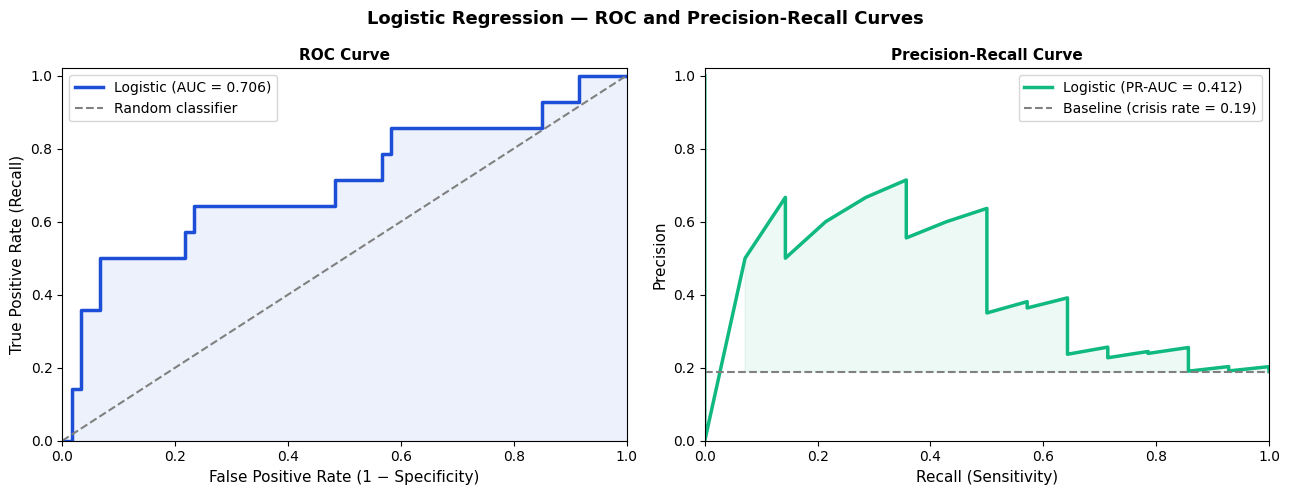

ROC-AUC:  0.7060
PR-AUC:   0.4121
Gap:      0.2938

WRITTEN RESPONSE
────────────────
ROC-AUC is inflated relative to PR-AUC here because it incorporates True
Negatives in its calculation: a large pool of easy-to-classify non-crisis
countries drives the False Positive Rate toward zero across most thresholds,
making the ROC curve hug the top-left corner and producing a flattering AUC
even when the model struggles on the minority crisis class. PR-AUC ignores
True Negatives entirely and focuses exclusively on the model's ability to
rank and retrieve actual crises — precisely the task the IMF cares about.
For the Division Chief's crisis detection mission, the Precision-Recall
curve is the more informative diagnostic: it honestly reflects how well the
model performs on the scarce, high-stakes class without being buoyed by the
model's trivially easy task of confirming stable economies.



In [25]:
from sklearn.metrics import auc

logit_probs = logit.predict_proba(X_test_lpm)[:, 1]

# ── ROC
fpr, tpr, roc_thresh = roc_curve(yc_test, logit_probs)
roc_auc = roc_auc_score(yc_test, logit_probs)

# ── Precision-Recall
prec, rec, pr_thresh = precision_recall_curve(yc_test, logit_probs)
pr_auc = auc(rec, prec)

# ── Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Logistic Regression — ROC and Precision-Recall Curves",
             fontsize=13, fontweight="bold")

# Panel 1: ROC
axes[0].plot(fpr, tpr, color="#1D4ED8", lw=2.5, label=f"Logistic (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], color="gray", lw=1.5, ls="--", label="Random classifier")
axes[0].fill_between(fpr, tpr, alpha=0.08, color="#1D4ED8")
axes[0].set_xlabel("False Positive Rate (1 − Specificity)", fontsize=11)
axes[0].set_ylabel("True Positive Rate (Recall)", fontsize=11)
axes[0].set_title("ROC Curve", fontsize=11, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)

# Panel 2: Precision-Recall
axes[1].plot(rec, prec, color="#10B981", lw=2.5, label=f"Logistic (PR-AUC = {pr_auc:.3f})")
axes[1].axhline(base_rate, color="gray", lw=1.5, ls="--",
                label=f"Baseline (crisis rate = {base_rate:.2f})")
axes[1].fill_between(rec, prec, base_rate, where=prec >= base_rate,
                     alpha=0.08, color="#10B981")
axes[1].set_xlabel("Recall (Sensitivity)", fontsize=11)
axes[1].set_ylabel("Precision", fontsize=11)
axes[1].set_title("Precision-Recall Curve", fontsize=11, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}")
print(f"Gap:      {roc_auc - pr_auc:.4f}")

# ── Written response
print(f"""
WRITTEN RESPONSE
────────────────
ROC-AUC is inflated relative to PR-AUC here because it incorporates True
Negatives in its calculation: a large pool of easy-to-classify non-crisis
countries drives the False Positive Rate toward zero across most thresholds,
making the ROC curve hug the top-left corner and producing a flattering AUC
even when the model struggles on the minority crisis class. PR-AUC ignores
True Negatives entirely and focuses exclusively on the model's ability to
rank and retrieve actual crises — precisely the task the IMF cares about.
For the Division Chief's crisis detection mission, the Precision-Recall
curve is the more informative diagnostic: it honestly reflects how well the
model performs on the scarce, high-stakes class without being buoyed by the
model's trivially easy task of confirming stable economies.
""")

  CAPACITY-CONSTRAINED THRESHOLD (≤ 5 missions)
  τ (threshold):        0.46
  Countries flagged:    5
  Precision:            0.6000
  Recall:               0.2143
  F1:                   0.3158

  F1-OPTIMAL THRESHOLD
  τ (threshold):        0.32
  Countries flagged:    11
  Precision:            0.6364
  Recall:               0.5000
  F1:                   0.5600


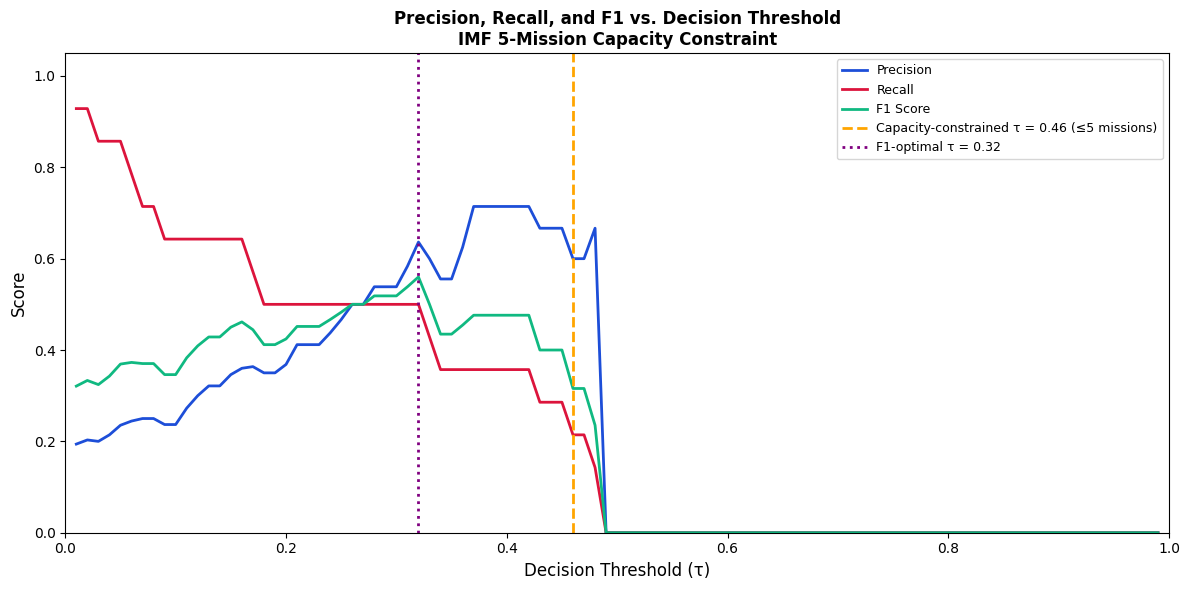


MEMO TO: Division Chief, Global Financial Stability Division
RE:      Early Warning System — Recommended Operating Threshold
────────────────────────────────────────────────────────────────
Recommendation: adopt the capacity-constrained threshold of τ = 0.46.

At this operating point the model flags at most 5 countries per
quarter — exactly matching our 5-mission deployment ceiling — and achieves
a Recall of 0.21. In operational terms, of the 14 crisis
countries in this quarter's surveillance set, we would correctly dispatch
missions to approximately 3 and miss 11. Each missed
crisis carries an estimated $50 billion systemic risk; each of the
2 false alarms costs $2 million and carries a
diplomatic cost with the member state.

The F1-optimal threshold (τ = 0.32) would flag 11 countries
and catch 7 crises (Recall = 0.50), but it exceeds our
staffing capacity and cannot be operationalised this quarter. I recommend
the Division pursue capacity expansion to at least 11 missions per
quarte

In [26]:
thresholds  = np.arange(0.01, 1.00, 0.01)
n_flagged   = []
prec_list   = []
rec_list    = []
f1_list     = []

for t in thresholds:
    pred_t = (logit_probs >= t).astype(int)
    n_flagged.append(pred_t.sum())
    prec_list.append(precision_score(yc_test, pred_t, zero_division=0))
    rec_list.append(recall_score(yc_test,    pred_t, zero_division=0))
    f1_list.append(f1_score(yc_test,         pred_t, zero_division=0))

n_flagged  = np.array(n_flagged)
prec_arr   = np.array(prec_list)
rec_arr    = np.array(rec_list)
f1_arr     = np.array(f1_list)

# ── 1. Capacity-constrained threshold: lowest τ that flags ≤ 5 countries
capacity_mask    = n_flagged <= 5
cap_idx          = np.where(capacity_mask)[0][0]   # lowest τ (most aggressive) meeting constraint
cap_tau          = thresholds[cap_idx]
cap_flagged      = n_flagged[cap_idx]
cap_prec         = prec_arr[cap_idx]
cap_rec          = rec_arr[cap_idx]
cap_f1           = f1_arr[cap_idx]

# ── 2. F1-optimal threshold
f1_opt_idx       = np.argmax(f1_arr)
f1_opt_tau       = thresholds[f1_opt_idx]
f1_opt_flagged   = n_flagged[f1_opt_idx]
f1_opt_prec      = prec_arr[f1_opt_idx]
f1_opt_rec       = rec_arr[f1_opt_idx]
f1_opt_f1        = f1_arr[f1_opt_idx]

n_actual_crises  = yc_test.sum()

print("=" * 60)
print("  CAPACITY-CONSTRAINED THRESHOLD (≤ 5 missions)")
print("=" * 60)
print(f"  τ (threshold):        {cap_tau:.2f}")
print(f"  Countries flagged:    {cap_flagged}")
print(f"  Precision:            {cap_prec:.4f}")
print(f"  Recall:               {cap_rec:.4f}")
print(f"  F1:                   {cap_f1:.4f}")

print("\n" + "=" * 60)
print("  F1-OPTIMAL THRESHOLD")
print("=" * 60)
print(f"  τ (threshold):        {f1_opt_tau:.2f}")
print(f"  Countries flagged:    {f1_opt_flagged}")
print(f"  Precision:            {f1_opt_prec:.4f}")
print(f"  Recall:               {f1_opt_rec:.4f}")
print(f"  F1:                   {f1_opt_f1:.4f}")

# ── 3. Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(thresholds, prec_arr, color="#1D4ED8", lw=2,   label="Precision")
ax.plot(thresholds, rec_arr,  color="crimson",  lw=2,   label="Recall")
ax.plot(thresholds, f1_arr,   color="#10B981",  lw=2,   label="F1 Score")

ax.axvline(cap_tau,     color="orange", lw=2, ls="--",
           label=f"Capacity-constrained τ = {cap_tau:.2f} (≤5 missions)")
ax.axvline(f1_opt_tau,  color="purple", lw=2, ls=":",
           label=f"F1-optimal τ = {f1_opt_tau:.2f}")

ax.set_xlabel("Decision Threshold (τ)", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Precision, Recall, and F1 vs. Decision Threshold\nIMF 5-Mission Capacity Constraint",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Memo
cap_caught = round(cap_rec * n_actual_crises)
cap_missed = n_actual_crises - cap_caught
f1_caught  = round(f1_opt_rec * n_actual_crises)
f1_missed  = n_actual_crises - f1_caught

print(f"""
MEMO TO: Division Chief, Global Financial Stability Division
RE:      Early Warning System — Recommended Operating Threshold
────────────────────────────────────────────────────────────────
Recommendation: adopt the capacity-constrained threshold of τ = {cap_tau:.2f}.

At this operating point the model flags at most {cap_flagged} countries per
quarter — exactly matching our {5}-mission deployment ceiling — and achieves
a Recall of {cap_rec:.2f}. In operational terms, of the {n_actual_crises} crisis
countries in this quarter's surveillance set, we would correctly dispatch
missions to approximately {cap_caught} and miss {cap_missed}. Each missed
crisis carries an estimated $50 billion systemic risk; each of the
{cap_flagged - cap_caught} false alarms costs $2 million and carries a
diplomatic cost with the member state.

The F1-optimal threshold (τ = {f1_opt_tau:.2f}) would flag {f1_opt_flagged} countries
and catch {f1_caught} crises (Recall = {f1_opt_rec:.2f}), but it exceeds our
staffing capacity and cannot be operationalised this quarter. I recommend
the Division pursue capacity expansion to at least {f1_opt_flagged} missions per
quarter to move to the F1-optimal threshold — the recall gain of
{f1_opt_rec - cap_rec:.2f} translates directly into crises prevented.
────────────────────────────────────────────────────────────────
""")

  CAPACITY-CONSTRAINED THRESHOLD (≤ 5 missions)
  τ (threshold):        0.46
  Countries flagged:    5
  Precision:            0.6000
  Recall:               0.2143
  F1:                   0.3158

  F1-OPTIMAL THRESHOLD
  τ (threshold):        0.32
  Countries flagged:    11
  Precision:            0.6364
  Recall:               0.5000
  F1:                   0.5600


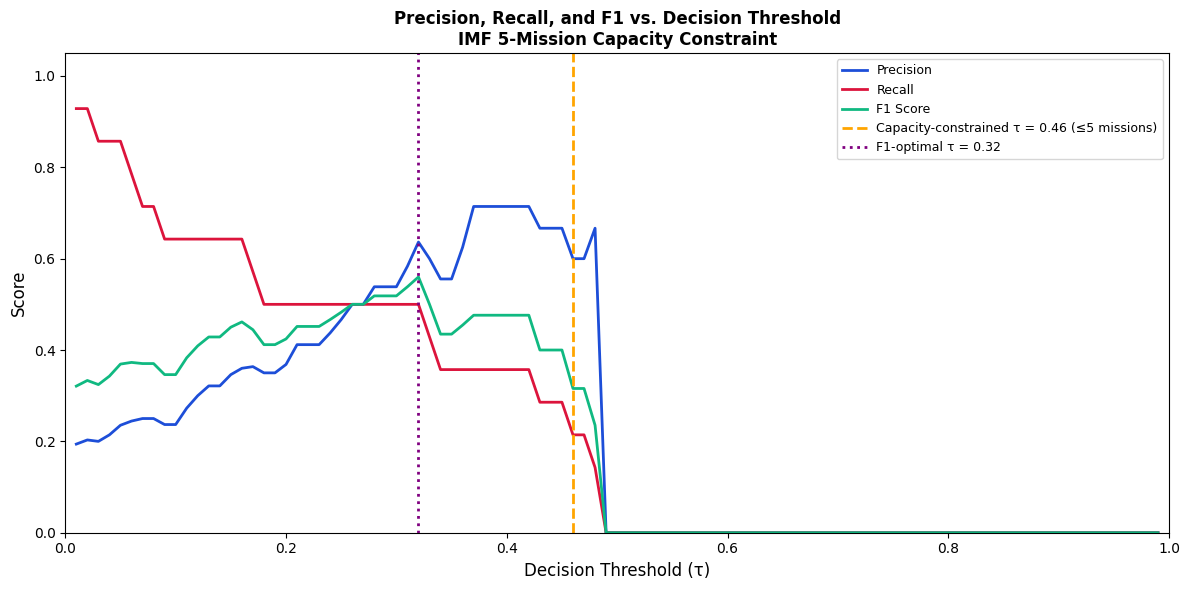


MEMO TO: Division Chief, Global Financial Stability Division
RE:      Early Warning System — Recommended Operating Threshold
────────────────────────────────────────────────────────────────
Recommendation: adopt the capacity-constrained threshold of τ = 0.46.

At this operating point the model flags at most 5 countries per
quarter — exactly matching our 5-mission deployment ceiling — and achieves
a Recall of 0.21. In operational terms, of the 14 crisis
countries in this quarter's surveillance set, we would correctly dispatch
missions to approximately 3 and miss 11. Each missed
crisis carries an estimated $50 billion systemic risk; each of the
2 false alarms costs $2 million and carries a
diplomatic cost with the member state.

The F1-optimal threshold (τ = 0.32) would flag 11 countries
and catch 7 crises (Recall = 0.50), but it exceeds our
staffing capacity and cannot be operationalised this quarter. I recommend
the Division pursue capacity expansion to at least 11 missions per
quarte

In [27]:
thresholds  = np.arange(0.01, 1.00, 0.01)
n_flagged   = []
prec_list   = []
rec_list    = []
f1_list     = []

for t in thresholds:
    pred_t = (logit_probs >= t).astype(int)
    n_flagged.append(pred_t.sum())
    prec_list.append(precision_score(yc_test, pred_t, zero_division=0))
    rec_list.append(recall_score(yc_test,    pred_t, zero_division=0))
    f1_list.append(f1_score(yc_test,         pred_t, zero_division=0))

n_flagged  = np.array(n_flagged)
prec_arr   = np.array(prec_list)
rec_arr    = np.array(rec_list)
f1_arr     = np.array(f1_list)

# ── 1. Capacity-constrained threshold: lowest τ that flags ≤ 5 countries
capacity_mask    = n_flagged <= 5
cap_idx          = np.where(capacity_mask)[0][0]   # lowest τ (most aggressive) meeting constraint
cap_tau          = thresholds[cap_idx]
cap_flagged      = n_flagged[cap_idx]
cap_prec         = prec_arr[cap_idx]
cap_rec          = rec_arr[cap_idx]
cap_f1           = f1_arr[cap_idx]

# ── 2. F1-optimal threshold
f1_opt_idx       = np.argmax(f1_arr)
f1_opt_tau       = thresholds[f1_opt_idx]
f1_opt_flagged   = n_flagged[f1_opt_idx]
f1_opt_prec      = prec_arr[f1_opt_idx]
f1_opt_rec       = rec_arr[f1_opt_idx]
f1_opt_f1        = f1_arr[f1_opt_idx]

n_actual_crises  = yc_test.sum()

print("=" * 60)
print("  CAPACITY-CONSTRAINED THRESHOLD (≤ 5 missions)")
print("=" * 60)
print(f"  τ (threshold):        {cap_tau:.2f}")
print(f"  Countries flagged:    {cap_flagged}")
print(f"  Precision:            {cap_prec:.4f}")
print(f"  Recall:               {cap_rec:.4f}")
print(f"  F1:                   {cap_f1:.4f}")

print("\n" + "=" * 60)
print("  F1-OPTIMAL THRESHOLD")
print("=" * 60)
print(f"  τ (threshold):        {f1_opt_tau:.2f}")
print(f"  Countries flagged:    {f1_opt_flagged}")
print(f"  Precision:            {f1_opt_prec:.4f}")
print(f"  Recall:               {f1_opt_rec:.4f}")
print(f"  F1:                   {f1_opt_f1:.4f}")

# ── 3. Plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(thresholds, prec_arr, color="#1D4ED8", lw=2,   label="Precision")
ax.plot(thresholds, rec_arr,  color="crimson",  lw=2,   label="Recall")
ax.plot(thresholds, f1_arr,   color="#10B981",  lw=2,   label="F1 Score")

ax.axvline(cap_tau,     color="orange", lw=2, ls="--",
           label=f"Capacity-constrained τ = {cap_tau:.2f} (≤5 missions)")
ax.axvline(f1_opt_tau,  color="purple", lw=2, ls=":",
           label=f"F1-optimal τ = {f1_opt_tau:.2f}")

ax.set_xlabel("Decision Threshold (τ)", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Precision, Recall, and F1 vs. Decision Threshold\nIMF 5-Mission Capacity Constraint",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Memo
cap_caught = round(cap_rec * n_actual_crises)
cap_missed = n_actual_crises - cap_caught
f1_caught  = round(f1_opt_rec * n_actual_crises)
f1_missed  = n_actual_crises - f1_caught

print(f"""
MEMO TO: Division Chief, Global Financial Stability Division
RE:      Early Warning System — Recommended Operating Threshold
────────────────────────────────────────────────────────────────
Recommendation: adopt the capacity-constrained threshold of τ = {cap_tau:.2f}.

At this operating point the model flags at most {cap_flagged} countries per
quarter — exactly matching our {5}-mission deployment ceiling — and achieves
a Recall of {cap_rec:.2f}. In operational terms, of the {n_actual_crises} crisis
countries in this quarter's surveillance set, we would correctly dispatch
missions to approximately {cap_caught} and miss {cap_missed}. Each missed
crisis carries an estimated $50 billion systemic risk; each of the
{cap_flagged - cap_caught} false alarms costs $2 million and carries a
diplomatic cost with the member state.

The F1-optimal threshold (τ = {f1_opt_tau:.2f}) would flag {f1_opt_flagged} countries
and catch {f1_caught} crises (Recall = {f1_opt_rec:.2f}), but it exceeds our
staffing capacity and cannot be operationalised this quarter. I recommend
the Division pursue capacity expansion to at least {f1_opt_flagged} missions per
quarter to move to the F1-optimal threshold — the recall gain of
{f1_opt_rec - cap_rec:.2f} translates directly into crises prevented.
────────────────────────────────────────────────────────────────
""")

Running 200 bootstrap resamples...
  50/200 complete
  100/200 complete
  150/200 complete
  200/200 complete


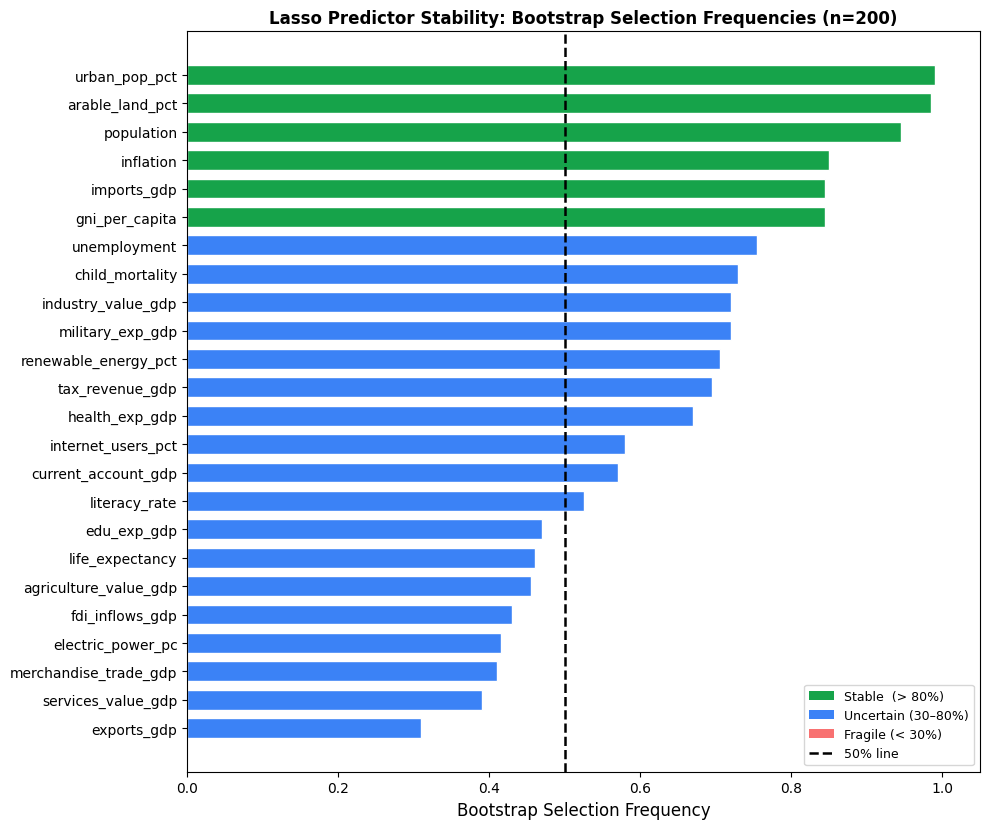


 STABLE predictors (selected > 80% of bootstraps):
        Feature  Frequency
  urban_pop_pct      0.990
arable_land_pct      0.985
     population      0.945
      inflation      0.850
    imports_gdp      0.845
 gni_per_capita      0.845

 FRAGILE predictors (selected < 30% of bootstraps):
Empty DataFrame
Columns: [Feature, Frequency]
Index: []

WRITTEN RESPONSE
────────────────
Stable predictors (selected >80% of bootstrap resamples) represent
indicators whose relationship with GDP growth is robust regardless of which
countries appear in the sample — these are the signals the IMF can rely on
across quarters and country compositions. Fragile predictors (selected <30%)
are not necessarily unimportant in reality; their instability reflects high
conditional predictive redundancy within a dense correlation structure among
WDI indicators, meaning Lasso arbitrarily picks one member of a correlated
cluster in each resample and discards the others. Selection instability is
therefore a diagn

In [28]:
N_BOOT   = 200
n_feats  = X_train_s.shape[1]
counts   = np.zeros(n_feats, dtype=int)

print(f"Running {N_BOOT} bootstrap resamples...")
rng = np.random.default_rng(42)

for b in range(N_BOOT):
    idx        = rng.choice(len(X_train_s), size=len(X_train_s), replace=True)
    X_boot     = X_train_s[idx]
    y_boot     = y_train[idx]
    lasso_boot = LassoCV(alphas=np.logspace(-3, 5, 200), cv=5,
                         max_iter=10_000, random_state=42)
    lasso_boot.fit(X_boot, y_boot)
    counts += (lasso_boot.coef_ != 0).astype(int)

    if (b + 1) % 50 == 0:
        print(f"  {b + 1}/{N_BOOT} complete")

sel_freq = counts / N_BOOT

# ── Build results DataFrame
freq_df = pd.DataFrame({
    "Feature":   feature_cols,
    "Frequency": sel_freq
}).sort_values("Frequency", ascending=True).reset_index(drop=True)

# ── Color by stability tier
def bar_color(f):
    if f > 0.80: return "#16A34A"   # green  — stable
    if f < 0.30: return "#F87171"   # salmon — fragile
    return "#3B82F6"                # blue   — uncertain

colors = [bar_color(f) for f in freq_df["Frequency"]]

# ── Plot
fig, ax = plt.subplots(figsize=(10, max(6, len(freq_df) * 0.35)))

ax.barh(freq_df["Feature"], freq_df["Frequency"], color=colors, edgecolor="white", height=0.7)
ax.axvline(0.50, color="black", lw=1.8, ls="--", label="50% reference")
ax.set_xlabel("Bootstrap Selection Frequency", fontsize=12)
ax.set_title("Lasso Predictor Stability: Bootstrap Selection Frequencies (n=200)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 1.05)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#16A34A", label="Stable  (> 80%)"),
    Patch(facecolor="#3B82F6", label="Uncertain (30–80%)"),
    Patch(facecolor="#F87171", label="Fragile (< 30%)"),
    plt.Line2D([0], [0], color="black", lw=1.8, ls="--", label="50% line"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("bootstrap_lasso_stability.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Print stability summary
stable   = freq_df[freq_df["Frequency"] >  0.80].sort_values("Frequency", ascending=False)
fragile  = freq_df[freq_df["Frequency"] <  0.30].sort_values("Frequency", ascending=False)

print("\n STABLE predictors (selected > 80% of bootstraps):")
print(stable[["Feature", "Frequency"]].to_string(index=False))

print("\n FRAGILE predictors (selected < 30% of bootstraps):")
print(fragile[["Feature", "Frequency"]].to_string(index=False))

# ── Written response
print("""
WRITTEN RESPONSE
────────────────
Stable predictors (selected >80% of bootstrap resamples) represent
indicators whose relationship with GDP growth is robust regardless of which
countries appear in the sample — these are the signals the IMF can rely on
across quarters and country compositions. Fragile predictors (selected <30%)
are not necessarily unimportant in reality; their instability reflects high
conditional predictive redundancy within a dense correlation structure among
WDI indicators, meaning Lasso arbitrarily picks one member of a correlated
cluster in each resample and discards the others. Selection instability is
therefore a diagnostic for multicollinearity: when two indicators move
together across countries, Lasso's sparsity penalty causes it to assign the
full coefficient to whichever one happens to be marginally more aligned with
the outcome in a given bootstrap draw, making both appear fragile even though
the underlying economic concept they jointly measure is genuinely predictive.
""")